# Plots
Loads all scenario results and produces all figures.
**Run all scenario notebooks first.**

## Load all scenario results

In [144]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import seaborn as sns
from pathlib import Path
from model_functions import load_remind_data
from model_functions import compare_remind_h2
# Legends
from matplotlib.lines import Line2D

data_folder = Path.cwd().parent / 'data' / 'processed'

scenario_files = {
    'L-Baseline': 'low_baseline.pkl',
    'L-DRI Scale-Up': 'low_dri.pkl',
    'L-Technology': 'low_tech.pkl',
    'L-Full Transition': 'low_full.pkl',
    'M-Baseline': 'med_baseline.pkl',
    'M-DRI Scale-Up': 'med_dri.pkl',
    'M-Technology': 'med_tech.pkl',
    'M-Full Transition': 'med_full.pkl',    
    'H-Baseline': 'high_baseline.pkl',
    'H-DRI Scale-Up': 'high_dri.pkl',
    'H-Technology': 'high_tech.pkl',
    'H-Full Transition': 'high_full.pkl'
}

scenarios = {}
for name, fname in scenario_files.items():
    with open(data_folder / fname, 'rb') as f:
        scenarios[name] = pickle.load(f)
    print(f'Loaded: {name}')

# Shared
baseline   = scenarios['M-Baseline']
years      = baseline['years']
plot_years = baseline['plot_years']

# Color palette
sc_colors = {
    'Baseline': '#4a4a4a',
    'Full transition':     '#1a5c3a',
    'Delayed transition':    '#8B1A1A',
    'Circular Economy':    '#1B4F8A',
    'Technology':   '#0D6B5E',
}

wsa_years  = list(baseline['wsa_production'].keys())
wsa_values = [v * 1e6 for v in baseline['wsa_production'].values()]

file_paths = {
    'SSP2 Current policies':  r'C:\Users\idapo\master_thesis\master-1\electrolysers\data\raw\future\REMIND_generic_C_SMIPv08-M-SSP2-NPi2025-def-rem-6.mif',
    'SSP2 Carbon price ~400': r'C:\Users\idapo\master_thesis\master-1\electrolysers\data\raw\future\REMIND_generic_C_SMIPv08-L-SSP2-PkPrice400-def-rem-6.mif',
    'SSP1 Ambitious':         r'C:\Users\idapo\master_thesis\master-1\electrolysers\data\raw\future\REMIND_generic_C_SMIPv08-VLLO-SSP1-PkPrice500-def-rem-6.mif',
}

remind_colors = {
    'SSP2 Current policies':  '#8B1A1A',
    'SSP2 Carbon price ~400': '#cf9140',
    'SSP1 Ambitious':         '#1a5c3a',
}

remind_data   = load_remind_data(file_paths)
remind_years  = list(remind_data.values())[0]['years']
h2_interp     = compare_remind_h2(scenarios, remind_data)


demand_levels  = ['L', 'M', 'H']
ambition_levels = ['Baseline', 'DRI Scale-Up', 'Technology', 'Full Transition']

demand_labels  = {
    'L': 'Low demand (6 t/capita)',
    'M': 'Medium demand (11 t/capita)',
    'H': 'High demand (16 t/capita)',
}

demand_colors  = {
    'L': '#2e7d32',
    'M': '#e65100',
    'H': '#b71c1c',
}

ambition_styles = {
    'Baseline':        ':',
    'DRI Scale-Up':    '--',
    'Technology':      '-.',
    'Full Transition': '-',
}

ambition_widths = {
    'Baseline': 1.2, 'DRI Scale-Up': 1.5,
    'Technology': 1.8, 'Full Transition': 2.2,
}

Loaded: L-Baseline
Loaded: L-DRI Scale-Up
Loaded: L-Technology
Loaded: L-Full Transition
Loaded: M-Baseline
Loaded: M-DRI Scale-Up
Loaded: M-Technology
Loaded: M-Full Transition
Loaded: H-Baseline
Loaded: H-DRI Scale-Up
Loaded: H-Technology
Loaded: H-Full Transition
Loaded: SSP2 Current policies  |  Green H2 2050: 50.9 Mt  |  Renew elec 2050: 53562 TWh  |  Electrolysis elec 2050: 2751 TWh
Loaded: SSP2 Carbon price ~400  |  Green H2 2050: 109.7 Mt  |  Renew elec 2050: 64298 TWh  |  Electrolysis elec 2050: 5925 TWh
Loaded: SSP1 Ambitious  |  Green H2 2050: 301.7 Mt  |  Renew elec 2050: 88673 TWh  |  Electrolysis elec 2050: 16304 TWh


## 1. Total in-use steel stock — baseline

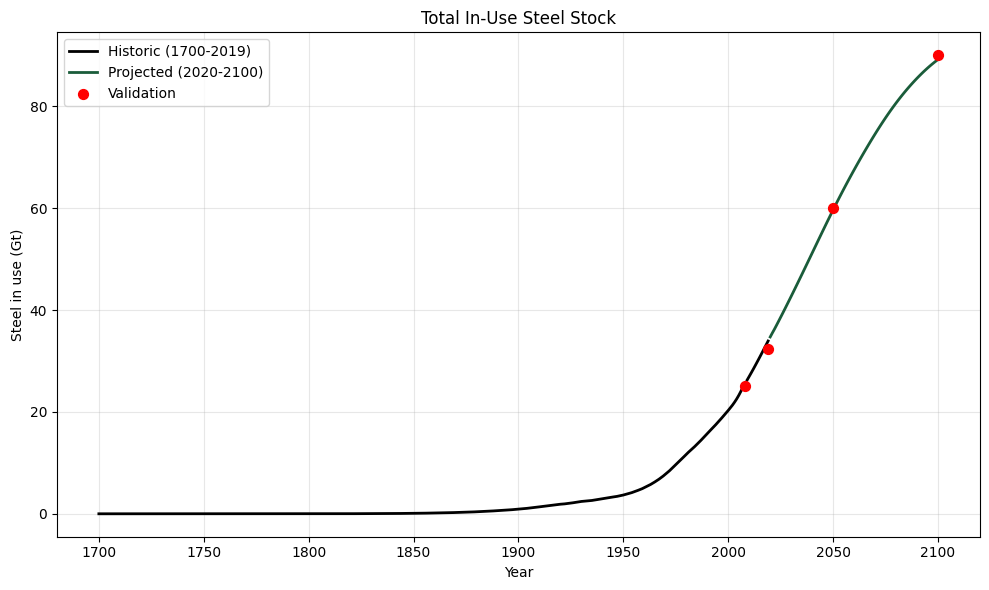

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
stock_df = baseline['stock_df']
hist   = stock_df[stock_df['type']=='historic']
recent = stock_df[stock_df['type']=='recent']
pred   = stock_df[stock_df['type']=='predicted']
ax.plot(hist['year'],   hist['total_stock']/1e9, color='black',   linewidth=2,   label='Historic (1700-2019)')
ax.plot(recent['year'], recent['total_stock']/1e9, color='black', linewidth=2)
ax.plot(pred['year'],   pred['total_stock']/1e9,  color='#1a5c3a', linewidth=2, label='Projected (2020-2100)')
ax.scatter([2008, 2019, 2050, 2100], [25, 32.3, 60, 90], color='red', zorder=5, s=50, label='Validation')
ax.set_xlabel('Year'); ax.set_ylabel('Steel in use (Gt)')
ax.set_title('Total In-Use Steel Stock')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Save plot to vizualization folder
viz_folder = Path.cwd().parent / 'visualizations'
viz_folder.mkdir(exist_ok=True)
#fig.savefig(viz_folder / 'steel_stock_validation.png', dpi=300)

## 2. Total steel stock — all scenarios

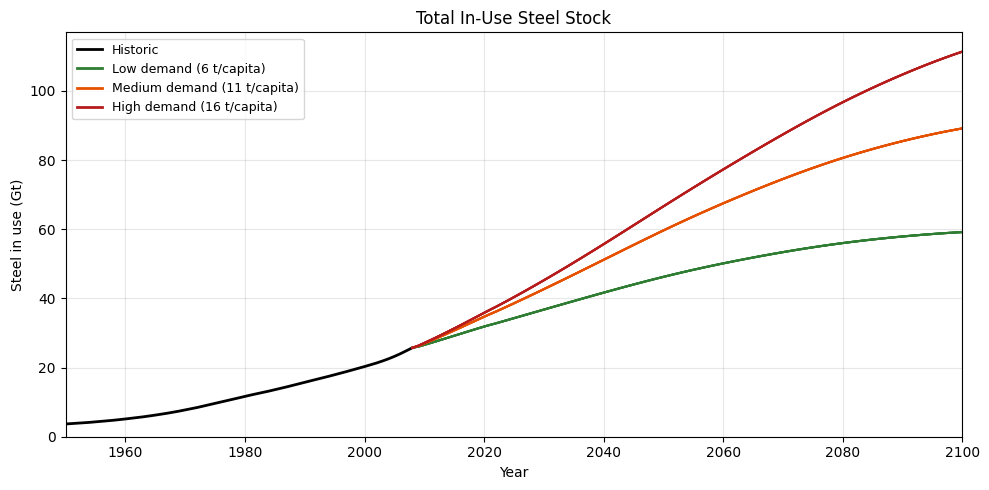

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
historic_plotted = False

for name, sc in scenarios.items():
    demand = name.split('-')[0]
    color  = demand_colors[demand]
    df     = sc['stock_df']

    hist = df[df['type'] == 'historic']
    pred = df[df['type'].isin(['recent', 'predicted'])]

    # Connect projected line to last actual data point
    last_hist = hist.iloc[[-1]]
    pred_connected = pd.concat([last_hist, pred])

    if not historic_plotted:
        ax.plot(hist['year'], hist['total_stock'] / 1e9,
                color='black', linewidth=2, label='Historic')
        historic_plotted = True

    ax.plot(pred_connected['year'], pred_connected['total_stock'] / 1e9,
            color=color, linewidth=1.5)


demand_handles = [
    Line2D([0], [0], color=demand_colors['L'], linewidth=2, label='Low demand (6 t/capita)'),
    Line2D([0], [0], color=demand_colors['M'], linewidth=2, label='Medium demand (11 t/capita)'),
    Line2D([0], [0], color=demand_colors['H'], linewidth=2, label='High demand (16 t/capita)'),
]

historic_handle = [Line2D([0], [0], color='black', linewidth=2, label='Historic')]


ax.set_xlabel('Year'); ax.set_ylabel('Steel in use (Gt)')
ax.set_title('Total In-Use Steel Stock')
ax.set_xlim(1950, 2100); ax.set_ylim(0)
ax.grid(True, alpha=0.3)
plt.legend(handles=historic_handle + demand_handles, loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

# Save plot to vizualization folder
#fig.savefig(viz_folder / 'steel_stock_projection.png', dpi=300)

## 3. Total crude steel needed vs WSA — baseline

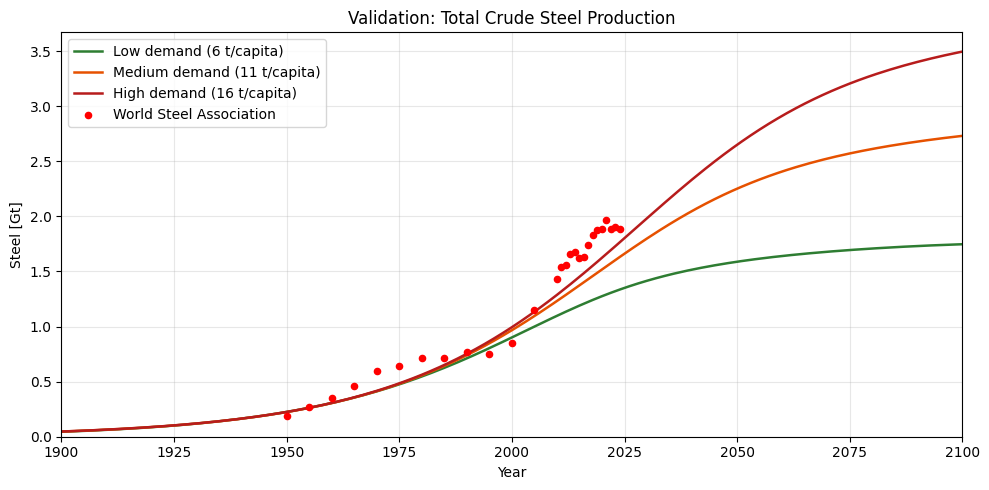

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

# One validation line per demand level (baselines only)
validation_scenarios = {
    'L-Baseline': ('Low demand (6 t/capita)',  demand_colors['L']),
    'M-Baseline': ('Medium demand (11 t/capita)', demand_colors['M']),
    'H-Baseline': ('High demand (16 t/capita)', demand_colors['H']),
}

for sc_name, (label, color) in validation_scenarios.items():
    results = scenarios[sc_name]['results']
    ax.plot(results['Year'], results['total_steel_needed'] / 1e9,
            color=color, linewidth=1.8, label=label)

# WSA validation scatter
ax.scatter(wsa_years, [v / 1e9 for v in wsa_values],
           color='red', s=20, zorder=5, label='World Steel Association')

ax.set_xlabel('Year'); ax.set_ylabel('Steel [Gt]')
ax.set_title('Validation: Total Crude Steel Production')
ax.set_xlim(1900, 2100); ax.set_ylim(0)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Save plot to vizualization folder
#fig.savefig(viz_folder / 'steel_validation.png', dpi=300)

## 4. Steel supply transition — baseline

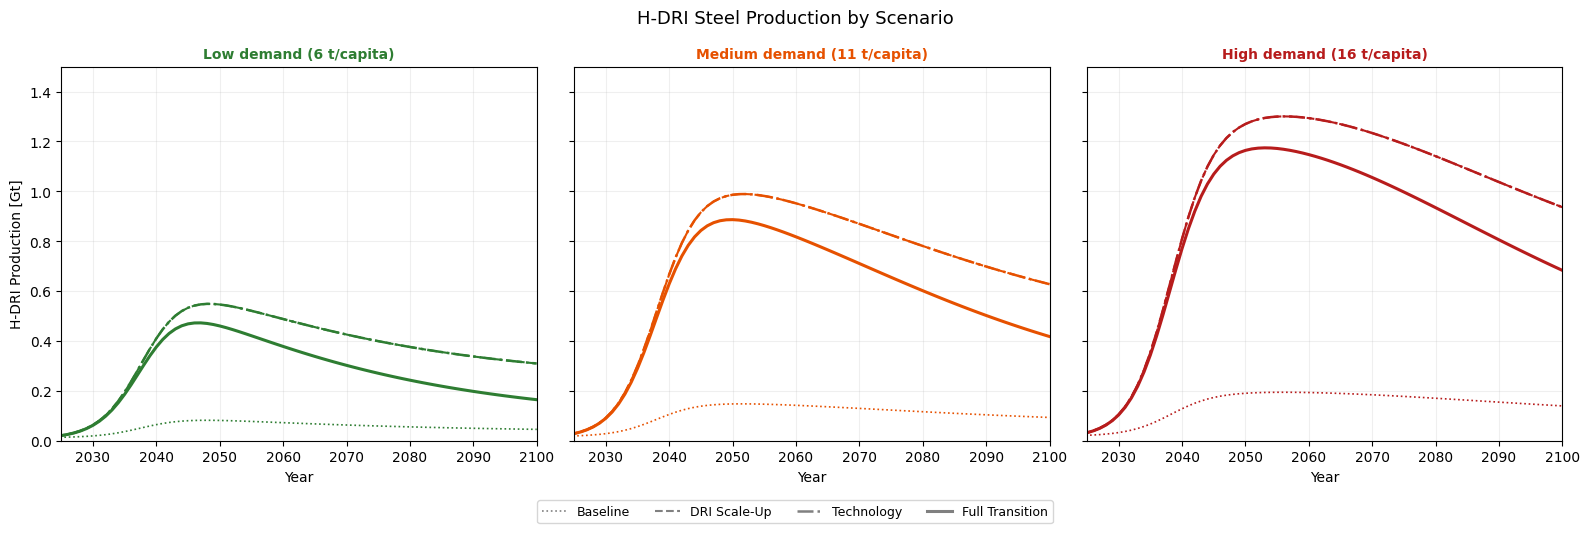

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, sharex=True)
fig.suptitle('H-DRI Steel Production by Scenario', fontsize=13)

for c, demand in enumerate(demand_levels):
    ax = axes[c]
    for ambition in ambition_levels:
        name = f'{demand}-{ambition}'
        dri  = scenarios[name]['production']['DRI Production'] / 1e9
        ax.plot(plot_years, dri,
                color=demand_colors[demand],
                linestyle=ambition_styles[ambition],
                linewidth=ambition_widths[ambition])

    ax.set_title(demand_labels[demand], fontsize=10,
                 fontweight='bold', color=demand_colors[demand])
    ax.set_xlabel('Year')
    ax.set_xlim(2025, 2100); ax.set_ylim(0, 1.5)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('H-DRI Production [Gt]')

ambition_handles = [
    Line2D([0], [0], color='gray', linestyle=ambition_styles[a],
           linewidth=ambition_widths[a], label=a) for a in ambition_levels
]
fig.legend(handles=ambition_handles, loc='lower center',
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.show()

# Save plot to vizualization folder
#fig.savefig(viz_folder / 'DRI_supply.png', dpi=300)

## 5. CO2 emissions — all scenarios

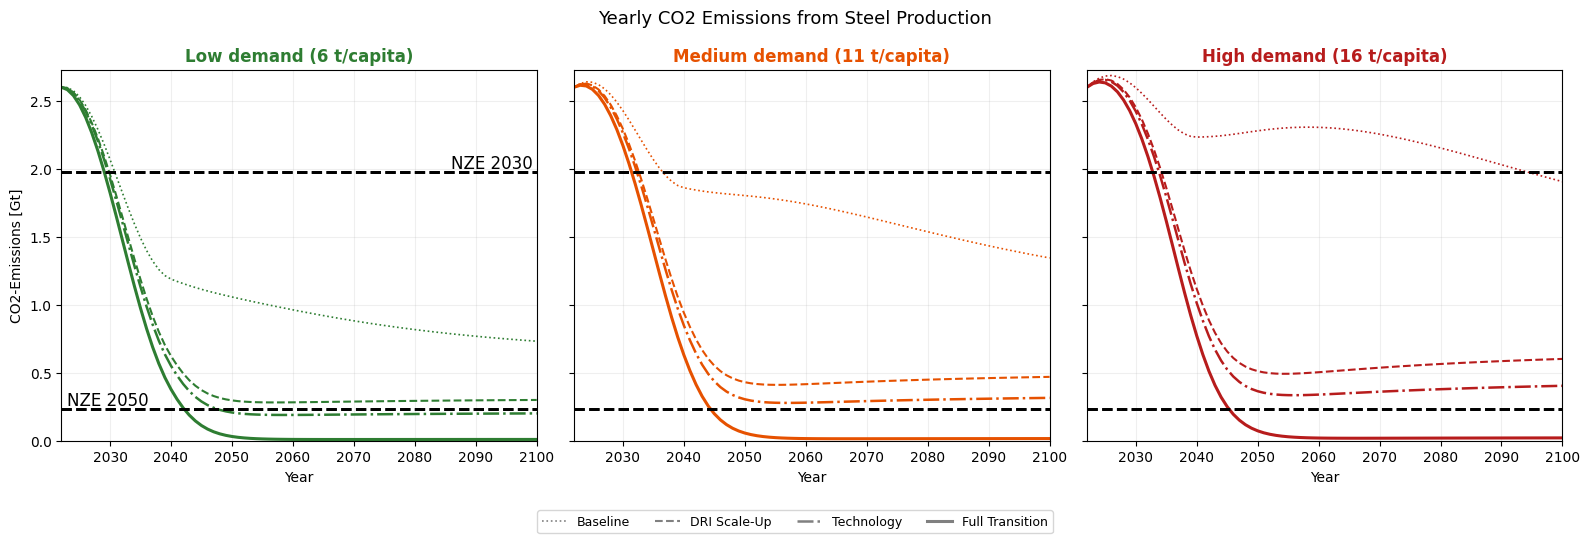

In [137]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, sharex=True)
fig.suptitle('Yearly CO2 Emissions from Steel Production', fontsize=13)

iea_2030_target = 1976 / 1e3
iea_2050_target = 234  / 1e3

for c, demand in enumerate(demand_levels):
    ax = axes[c]

    for ambition in ambition_levels:
        name = f'{demand}-{ambition}'
        ax.plot(plot_years, em[name],
                color=demand_colors[demand],
                linestyle=ambition_styles[ambition],
                linewidth=ambition_widths[ambition],
                label=ambition)

    # NZE crosshair markers
    for year, target, label_txt in [
        (2030, iea_2030_target, 'NZE 2030'),
        (2050, iea_2050_target, 'NZE 2050'),
    ]:
        # Horizontal dotted line from x-axis up to target
        ax.axhline(iea_2030_target, color='black', linewidth=2,
               linestyle='--', zorder=9)
        ax.axhline(iea_2050_target, color='black', linewidth=2,
               linestyle='--', zorder=9)
    if c == 0:
        ax.text(2086, iea_2030_target + 0.03, 'NZE 2030', fontsize=12)
        ax.text(2023, iea_2050_target + 0.03, 'NZE 2050', fontsize=12)

    ax.set_title(demand_labels[demand], fontsize=12, fontweight='bold',
                 color=demand_colors[demand])
    ax.set_xlabel('Year')
    ax.set_xlim(2022, 2100); ax.set_ylim(0)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('CO2-Emissions [Gt]')

ambition_handles = [
    Line2D([0], [0], color='gray', linestyle=ambition_styles[a],
           linewidth=ambition_widths[a], label=a) for a in ambition_levels
] 

fig.legend(handles=ambition_handles, loc='lower center',
           ncol=6, fontsize=9, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.show()

# Save plot to vizualization folder
#fig.savefig(viz_folder / 'steel_emissions_scenarios.png', dpi=300)

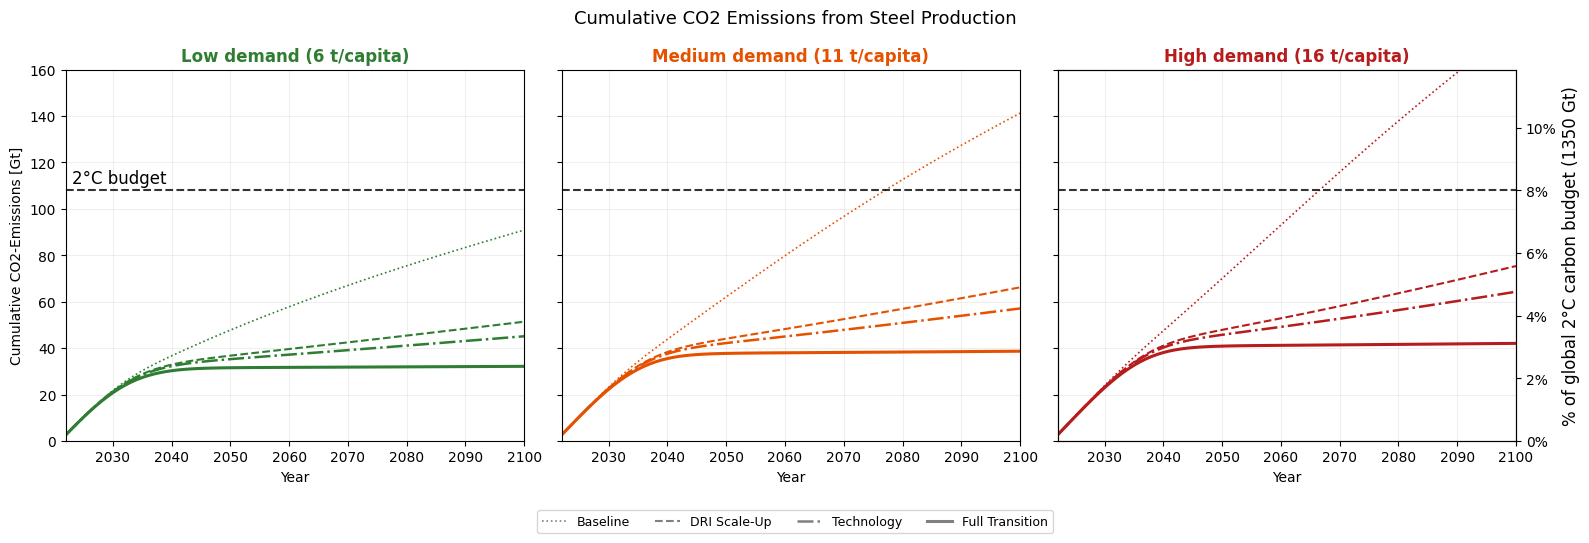

In [ ]:
# Uses calibrated em dict from the yearly emissions plot
em_cum = {name: np.cumsum(em[name]) for name in scenarios}

budget_total   = 1350   # Gt CO2 — IPCC AR6 2°C budget
budget_2c      = 108    # Steel sector proportional share

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, sharex=True)
fig.suptitle('Cumulative CO2 Emissions from Steel Production', fontsize=13)

for c, demand in enumerate(demand_levels):
    ax = axes[c]

    for ambition in ambition_levels:
        name = f'{demand}-{ambition}'
        ax.plot(plot_years, em_cum[name],
                color=demand_colors[demand],
                linestyle=ambition_styles[ambition],
                linewidth=ambition_widths[ambition],
                label=ambition)

    # Carbon budget line
    ax.axhline(budget_2c, color='black', linewidth=1.5,
               linestyle='--', alpha=0.8)
    if c == 0:
        ax.text(2023, budget_2c + 1.5, '2°C budget', fontsize=12,
                color='black', va='bottom')

    ax.set_title(demand_labels[demand], fontsize=12,
                 fontweight='bold', color=demand_colors[demand])
    ax.set_xlabel('Year')
    ax.set_xlim(2022, 2100)
    ax.set_ylim(0, 160)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('Cumulative CO2-Emissions [Gt]')

# Secondary % axis on rightmost panel only
ax2 = axes[2].twinx()
ax2.set_ylim(0 / budget_total * 100, 160 / budget_total * 100)
ax2.set_ylabel('% of global 2°C carbon budget (1350 Gt)', fontsize=12)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

ambition_handles = [
    Line2D([0], [0], color='gray', linestyle=ambition_styles[a],
           linewidth=ambition_widths[a], label=a) for a in ambition_levels
]
fig.legend(handles=ambition_handles, loc='lower center',
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.show()

# Save plot to vizualization folder
#fig.savefig(viz_folder / 'steel_cumulative_emissions_scenarios.png', dpi=300)

## 6. CO2 by route

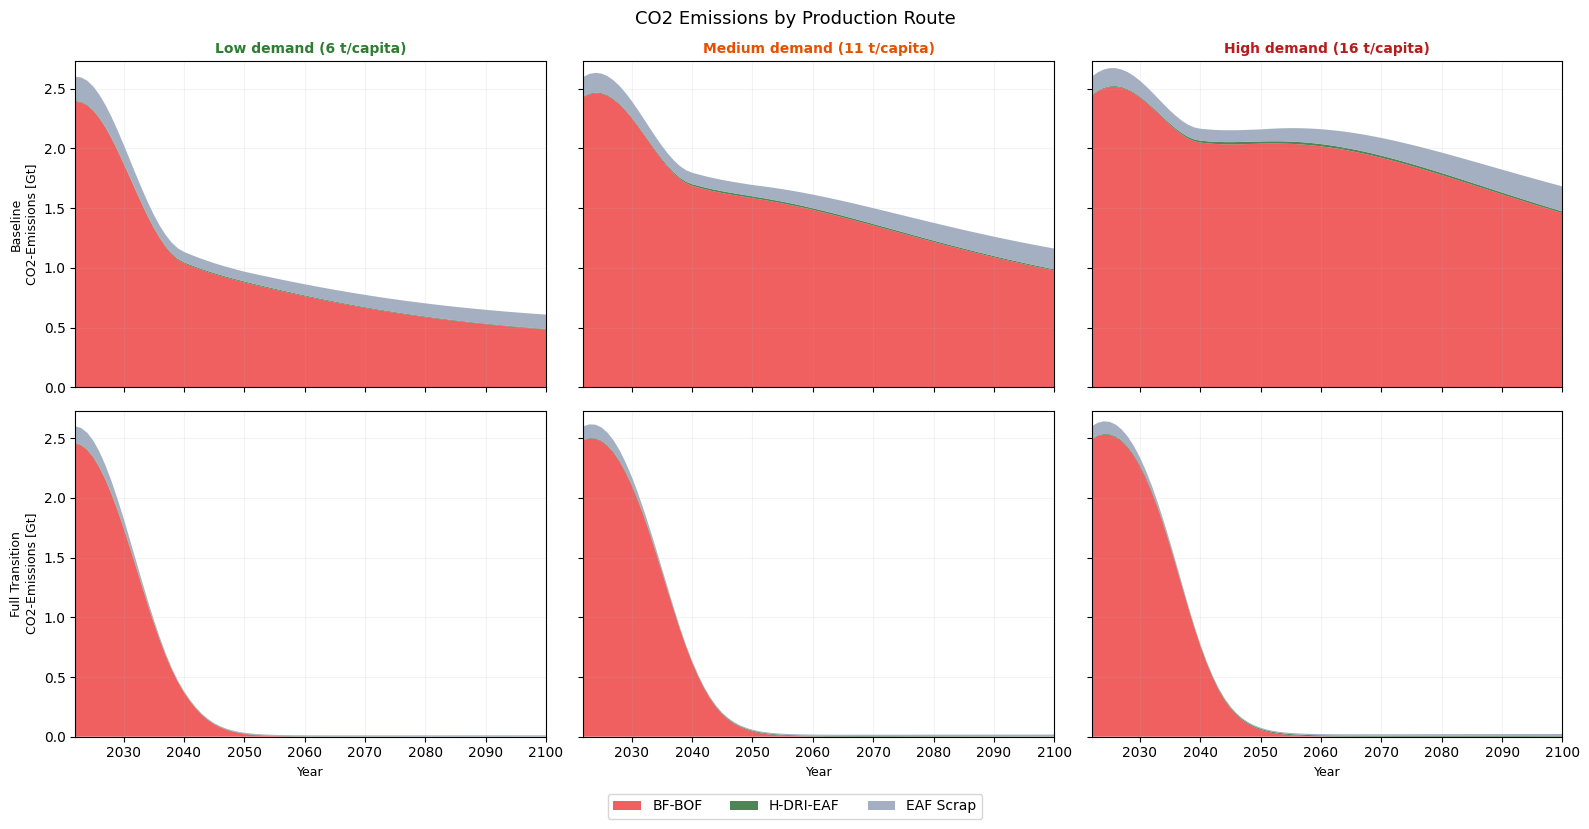

In [82]:
def get_route_emissions(sc, plot_years, iea_2022_emissions=2.6):
    em     = sc['emissions']
    bf_em  = em['BF Emissions']    / 1000
    dri_em = em['H-DRI Emissions'] / 1000
    eaf_em = em['EAF Emissions']   / 1000
    scale  = iea_2022_emissions / (bf_em[0] + dri_em[0] + eaf_em[0])
    t      = np.clip((plot_years - 2022) / (2040 - 2022), 0, 1)
    taper  = 0.5 * (1 - np.cos(np.pi * t))
    calib  = scale * (1 - taper) + 1.0 * taper
    return bf_em * calib, dri_em * calib, eaf_em * calib

route_rows   = ['Baseline', 'Full Transition']
route_colors = ['#ef4444', '#2e7038', '#94a3b8']
route_labels = ['BF-BOF', 'H-DRI-EAF', 'EAF Scrap']

fig, axes = plt.subplots(2, 3, figsize=(16, 8),
                          sharey=True, sharex=True)
fig.suptitle('CO2 Emissions by Production Route', fontsize=13)

for r, ambition in enumerate(route_rows):
    for c, demand in enumerate(demand_levels):
        ax  = axes[r][c]
        sc  = scenarios[f'{demand}-{ambition}']
        bf, dri, eaf = get_route_emissions(sc, plot_years)

        ax.stackplot(plot_years, bf, dri, eaf,
                     colors=route_colors, alpha=0.85)
        ax.set_xlim(2022, 2100); ax.set_ylim(0)
        ax.grid(alpha=0.15)

        if r == 0:
            ax.set_title(demand_labels[demand], fontsize=10,
                         fontweight='bold', color=demand_colors[demand])
        if c == 0:
            ax.set_ylabel(f'{ambition}\nCO2-Emissions [Gt]', fontsize=9)
        if r == 1:
            ax.set_xlabel('Year', fontsize=9)

# Shared legend
from matplotlib.patches import Patch
route_handles = [Patch(facecolor=c, alpha=0.85, label=l)
                 for c, l in zip(route_colors, route_labels)]
fig.legend(handles=route_handles, loc='lower center',
           ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig(viz_folder / 'steel_emissions_by_route.png',
            dpi=300, bbox_inches='tight')
plt.show()

# Save plot to vizualization folder
#fig.savefig(viz_folder / 'steel_emissions_by_route.png', dpi=300)

## 7. Hydrogen demand — all scenarios

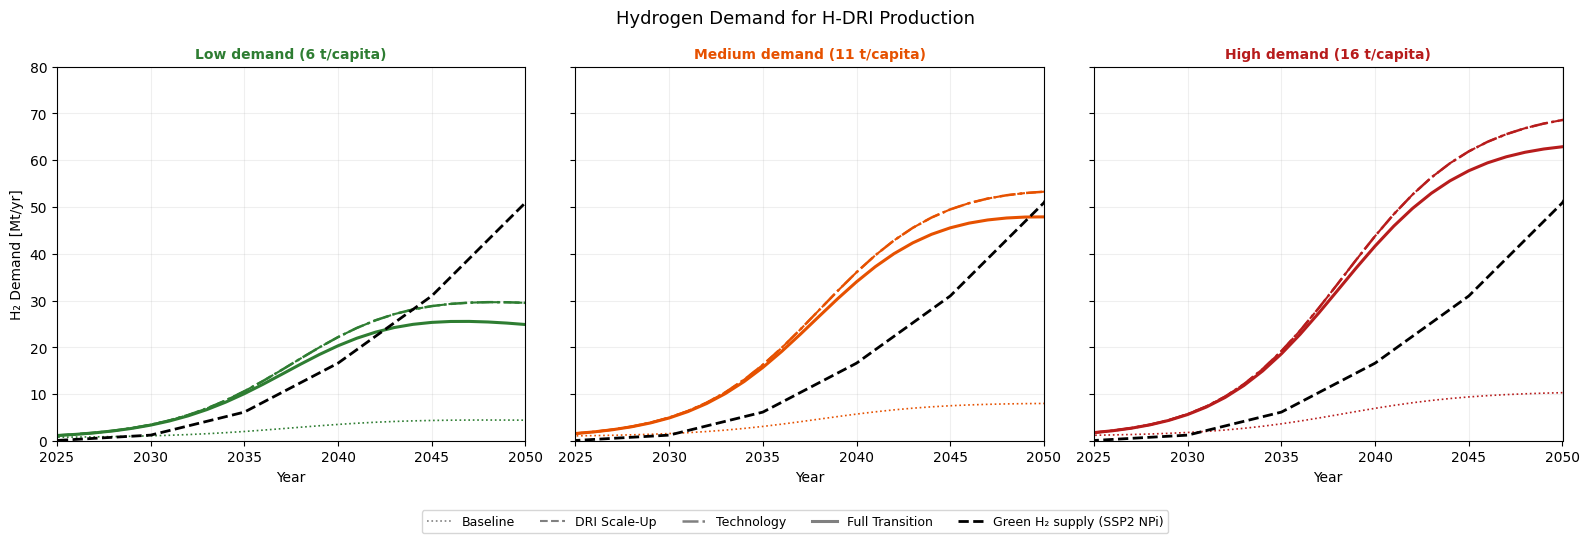

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, sharex=True)
fig.suptitle('Hydrogen Demand for H-DRI Production', fontsize=13)

remind_years = remind_data['SSP2 Current policies']['years']

for c, demand in enumerate(demand_levels):
    ax = axes[c]

    for ambition in ambition_levels:
        name = f'{demand}-{ambition}'
        ax.plot(plot_years,
                scenarios[name]['h2']['H2 Demand (Mt)'],
                color=demand_colors[demand],
                linestyle=ambition_styles[ambition],
                linewidth=ambition_widths[ambition],
                label=ambition)

    # SSP2 green H2 supply
    ax.plot(remind_years,
            remind_data['SSP2 Current policies']['green_h2'],
            color='black', linewidth=2, linestyle='--',
            label='Green H₂ supply (SSP2 NPi)')

    ax.set_title(demand_labels[demand], fontsize=10,
                 fontweight='bold', color=demand_colors[demand])
    ax.set_xlabel('Year')
    ax.set_xlim(2025, 2050)
    ax.set_ylim(0, 80)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('H₂ Demand [Mt/yr]')

from matplotlib.lines import Line2D
ambition_handles = [
    Line2D([0], [0], color='gray', linestyle=ambition_styles[a],
           linewidth=ambition_widths[a], label=a) for a in ambition_levels
] + [
    Line2D([0], [0], color='black', linewidth=2, linestyle='--',
           label='Green H₂ supply (SSP2 NPi)')
]
fig.legend(handles=ambition_handles, loc='lower center',
           ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.show()

# Save plot to vizualization folder
#fig.savefig(viz_folder / 'h2_demand_scenarios.png', dpi=300)

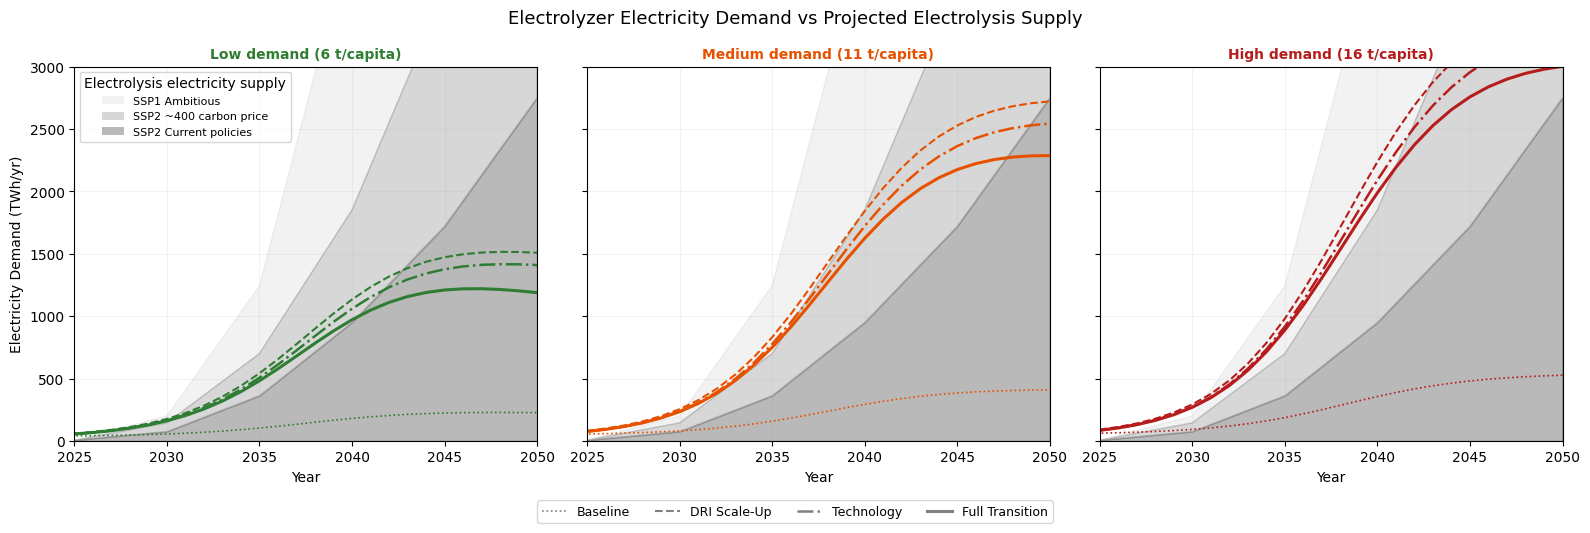

In [ ]:
# Interpolate SSP to annual years for smooth fill_between
annual_years = np.arange(2025, 2051)
ssp_annual   = {}
for ssp_name in remind_styles:
    f = interp1d(remind_years,
                 remind_data[ssp_name]['electrolysis_electricity'],
                 kind='linear', fill_value='extrapolate')
    ssp_annual[ssp_name] = f(annual_years)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, sharex=True)
fig.suptitle('Electrolyzer Electricity Demand vs Projected Electrolysis Supply', fontsize=13)

for c, demand in enumerate(demand_levels):
    ax = axes[c]

    # SSP policy zones as shaded bands
    ax.fill_between(annual_years, 0,
                    ssp_annual['SSP2 Current policies'],
                    alpha=0.3, color="#171717")
    ax.fill_between(annual_years,
                    ssp_annual['SSP2 Current policies'],
                    ssp_annual['SSP2 Carbon price ~400'],
                    alpha=0.2, color="#373737")
    ax.fill_between(annual_years,
                    ssp_annual['SSP2 Carbon price ~400'],
                    ssp_annual['SSP1 Ambitious'],
                    alpha=0.1, color="#838383")
    

    # SSP boundary lines (thin)
    for ssp_name, (_, color, _) in remind_styles.items():
        ax.plot(annual_years, ssp_annual[ssp_name],
                color=color, linewidth=0, linestyle='-')

    # Scenario demand lines
    for ambition in ambition_levels:
        name = f'{demand}-{ambition}'
        ax.plot(plot_years, elec[name],
                color=demand_colors[demand],
                linestyle=ambition_styles[ambition],
                linewidth=ambition_widths[ambition])

    # Zone labels (left panel only)
    if c == 0:
        mid_npi     = ssp_annual['SSP2 Current policies'][0]  / 2
        mid_carbon  = (ssp_annual['SSP2 Current policies'][0] +
                       ssp_annual['SSP2 Carbon price ~400'][0]) / 2
        mid_amb     = (ssp_annual['SSP2 Carbon price ~400'][0] +
                       ssp_annual['SSP1 Ambitious'][0])        / 2
    
    ax.set_title(demand_labels[demand], fontsize=10,
                 fontweight='bold', color=demand_colors[demand])
    ax.set_xlabel('Year')
    ax.set_xlim(2025, 2050); ax.set_ylim(0, 3000)
    ax.grid(True, alpha=0.15)

    ssp_handles = [
    Patch(facecolor='#838383', alpha=0.1, label='SSP1 Ambitious'),
    Patch(facecolor='#373737', alpha=0.2, label='SSP2 ~400 carbon price'),
    Patch(facecolor='#171717', alpha=0.3, label='SSP2 Current policies'),
]
axes[0].legend(handles=ssp_handles, fontsize=8,
               title='Electrolysis electricity supply', loc='upper left')

axes[0].set_ylabel('Electricity Demand (TWh/yr)')

ambition_handles = [
    Line2D([0], [0], color='gray', linestyle=ambition_styles[a],
           linewidth=ambition_widths[a], label=a) for a in ambition_levels
]
fig.legend(handles=ambition_handles, loc='lower center',
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
#plt.savefig(viz_folder / 'electrolyzer_electricity_all_scenarios.png',
#            dpi=300, bbox_inches='tight')
plt.show()

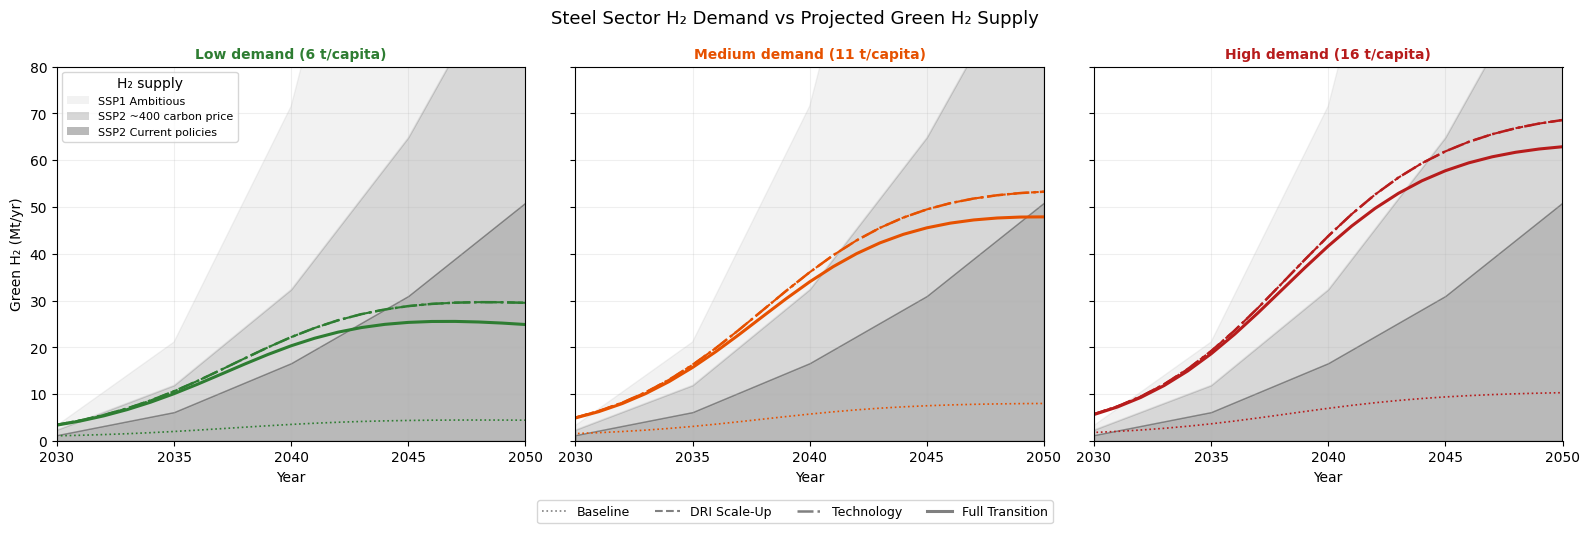

In [ ]:
# Interpolate SSP H2 supply to annual years
annual_years_h2 = np.arange(2030, 2051)
ssp_h2_annual   = {}
for ssp_name in ssp_styles:
    f = interp1d(remind_years, remind_data[ssp_name]['green_h2'],
                 kind='linear', fill_value='extrapolate')
    ssp_h2_annual[ssp_name] = f(annual_years_h2)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, sharex=True)
fig.suptitle('Steel Sector H₂ Demand vs Projected Green H₂ Supply', fontsize=13)

for c, demand in enumerate(demand_levels):
    ax = axes[c]

    # SSP zones as shaded bands
    ax.fill_between(annual_years_h2, 0,
                    ssp_h2_annual['SSP2 Current policies'],
                    alpha=0.3, color="#171717")
    ax.fill_between(annual_years_h2,
                    ssp_h2_annual['SSP2 Current policies'],
                    ssp_h2_annual['SSP2 Carbon price ~400'],
                    alpha=0.2, color="#373737")
    ax.fill_between(annual_years_h2,
                    ssp_h2_annual['SSP2 Carbon price ~400'],
                    ssp_h2_annual['SSP1 Ambitious'],
                    alpha=0.1, color="#838383")

    # SSP boundary lines (thin)
    for ssp_name, (_, col, _) in ssp_styles.items():
        ax.plot(annual_years_h2, ssp_h2_annual[ssp_name],
                color=col, linewidth=0, linestyle='-')

    # Scenario H2 demand lines
    for ambition in ambition_levels:
        name = f'{demand}-{ambition}'
        ax.plot(plot_years, scenarios[name]['h2']['H2 Demand (Mt)'],
                color=demand_colors[demand],
                linestyle=ambition_styles[ambition],
                linewidth=ambition_widths[ambition])

    ax.set_title(demand_labels[demand], fontsize=10,
                 fontweight='bold', color=demand_colors[demand])
    ax.set_xlabel('Year')
    ax.set_xlim(2030, 2050)
    ax.set_xticks(range(2030, 2051, 5))
    ax.set_ylim(0, 80)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('Green H₂ (Mt/yr)')

ambition_handles = [
    Line2D([0], [0], color='gray', linestyle=ambition_styles[a],
           linewidth=ambition_widths[a], label=a) for a in ambition_levels
]
ssp_patch_handles = [
    Patch(facecolor='#838383', alpha=0.1, label='SSP1 Ambitious'),
    Patch(facecolor='#373737', alpha=0.2, label='SSP2 ~400 carbon price'),
    Patch(facecolor='#171717', alpha=0.3, label='SSP2 Current policies'),
]

fig.legend(handles=ambition_handles, loc='lower center',
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.06))

axes[0].legend(handles=ssp_patch_handles, fontsize=8,
               title='H₂ supply', loc='upper left')

plt.tight_layout()
#plt.savefig(viz_folder / 'h2_demand_vs_supply_all_scenarios.png',
#            dpi=300, bbox_inches='tight')
plt.show()

## 8. Electrolyzer capacity — baseline

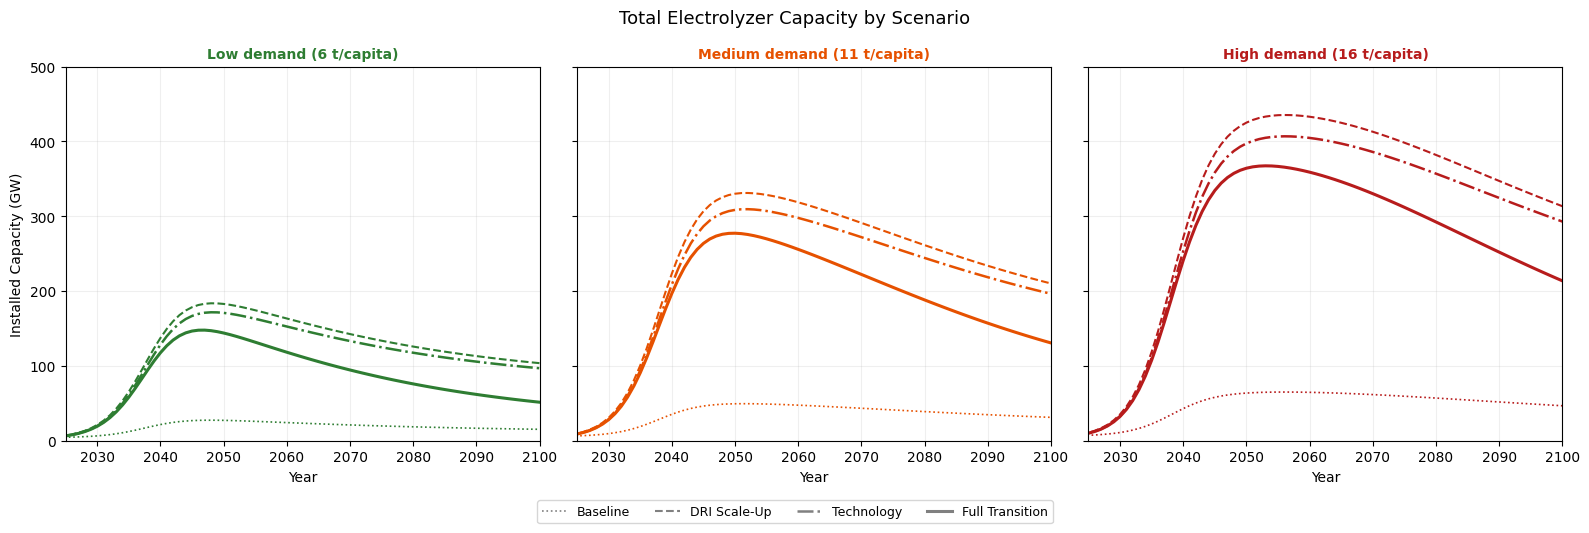

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, sharex=True)
fig.suptitle('Total Electrolyzer Capacity by Scenario', fontsize=13)

for c, demand in enumerate(demand_levels):
    ax = axes[c]
    for ambition in ambition_levels:
        name = f'{demand}-{ambition}'
        cap  = scenarios[name]['cap_results']
        total = cap['AEC'] + cap['PEM'] + cap['Other']
        ax.plot(plot_years, total,
                color=demand_colors[demand],
                linestyle=ambition_styles[ambition],
                linewidth=ambition_widths[ambition])

    ax.set_title(demand_labels[demand], fontsize=10,
                 fontweight='bold', color=demand_colors[demand])
    ax.set_xlabel('Year')
    ax.set_xlim(plot_years[3], plot_years[-1])
    ax.set_ylim(0, 500)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('Installed Capacity (GW)')

from matplotlib.lines import Line2D
ambition_handles = [
    Line2D([0], [0], color='gray', linestyle=ambition_styles[a],
           linewidth=ambition_widths[a], label=a) for a in ambition_levels
]
fig.legend(handles=ambition_handles, loc='lower center',
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
plt.savefig(viz_folder / 'electrolyzer_capacity_total_all_scenarios.png',
            dpi=300, bbox_inches='tight')
plt.show()

# Save plot to vizualization folder
#fig.savefig(viz_folder / 'electrolyzer_capacity_by_technology.png', dpi=300)

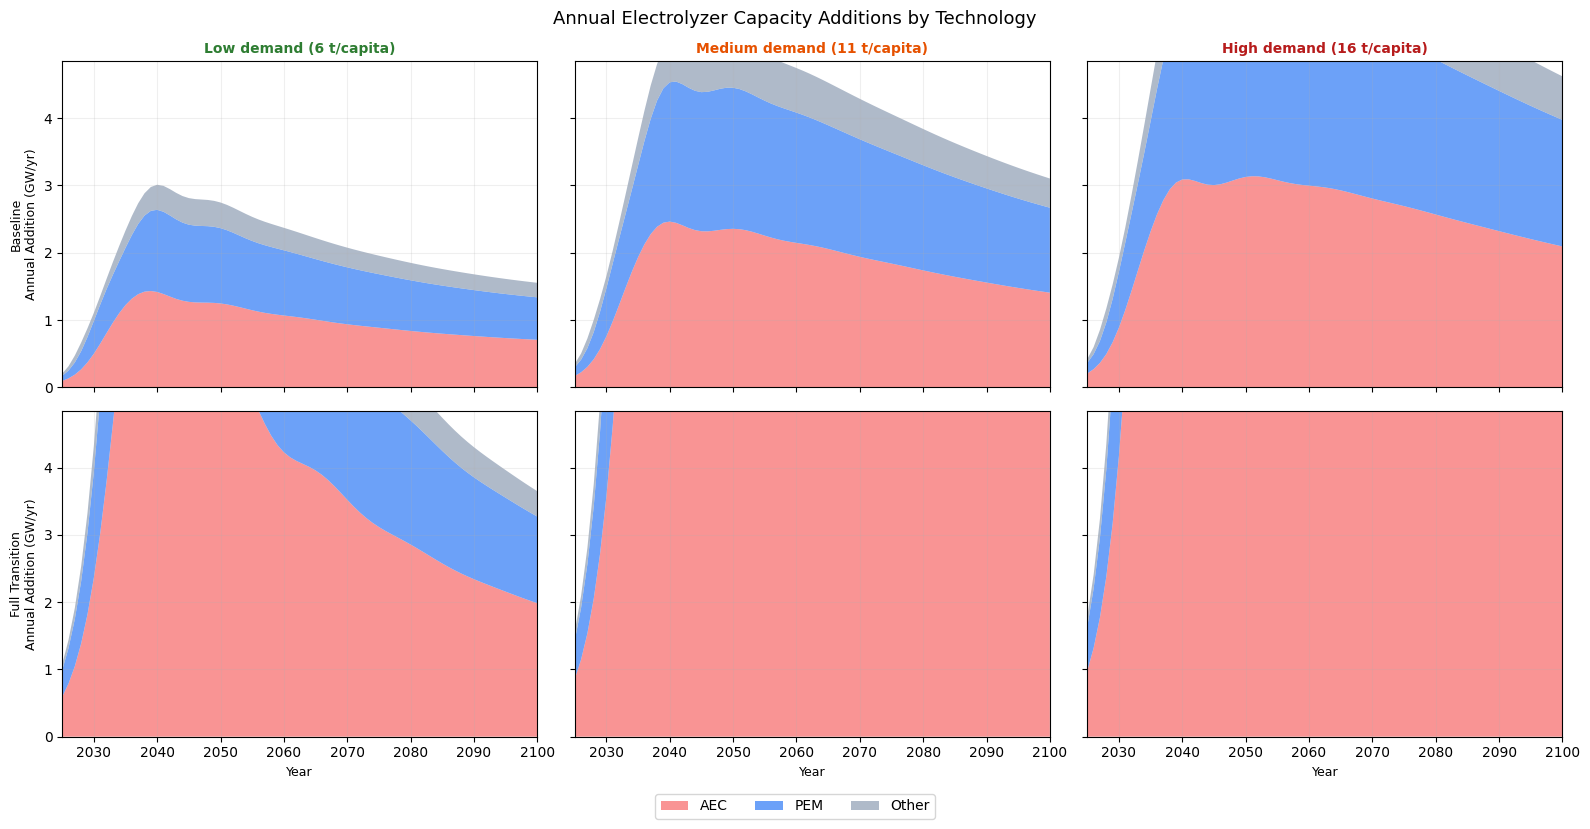

In [87]:
cap_colors = ['#f87171', '#3b82f6', '#94a3b8']
cap_labels  = ['AEC', 'PEM', 'Other']
cap_rows    = ['Baseline', 'Full Transition']

from matplotlib.patches import Patch
cap_handles = [Patch(facecolor=c, alpha=0.75, label=l)
               for c, l in zip(cap_colors, cap_labels)]

fig, axes = plt.subplots(2, 3, figsize=(16, 8),
                          sharey=True, sharex=True)
fig.suptitle('Annual Electrolyzer Capacity Additions by Technology', fontsize=13)

for r, ambition in enumerate(cap_rows):
    for c, demand in enumerate(demand_levels):
        ax  = axes[r][c]
        dsm = scenarios[f'{demand}-{ambition}']['dsm_elec']

        ax.stackplot(plot_years,
                     dsm['i_AEC'], dsm['i_PEM'], dsm['i_Other'],
                     colors=cap_colors, alpha=0.75)

        ax.set_xlim(plot_years[3], plot_years[-1])
        ax.set_ylim(0)
        ax.grid(True, alpha=0.2)

        if r == 0:
            ax.set_title(demand_labels[demand], fontsize=10,
                         fontweight='bold', color=demand_colors[demand])
        if c == 0:
            ax.set_ylabel(f'{ambition}\nAnnual Addition (GW/yr)', fontsize=9)
        if r == 1:
            ax.set_xlabel('Year', fontsize=9)

fig.legend(handles=cap_handles, loc='lower center',
           ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig(viz_folder / 'electrolyzer_additions_all_scenarios.png',
            dpi=300, bbox_inches='tight')
plt.show()

# Save plot to vizualization folder
#fig.savefig(viz_folder / 'electrolyzer_additions_by_technology.png', dpi=300)

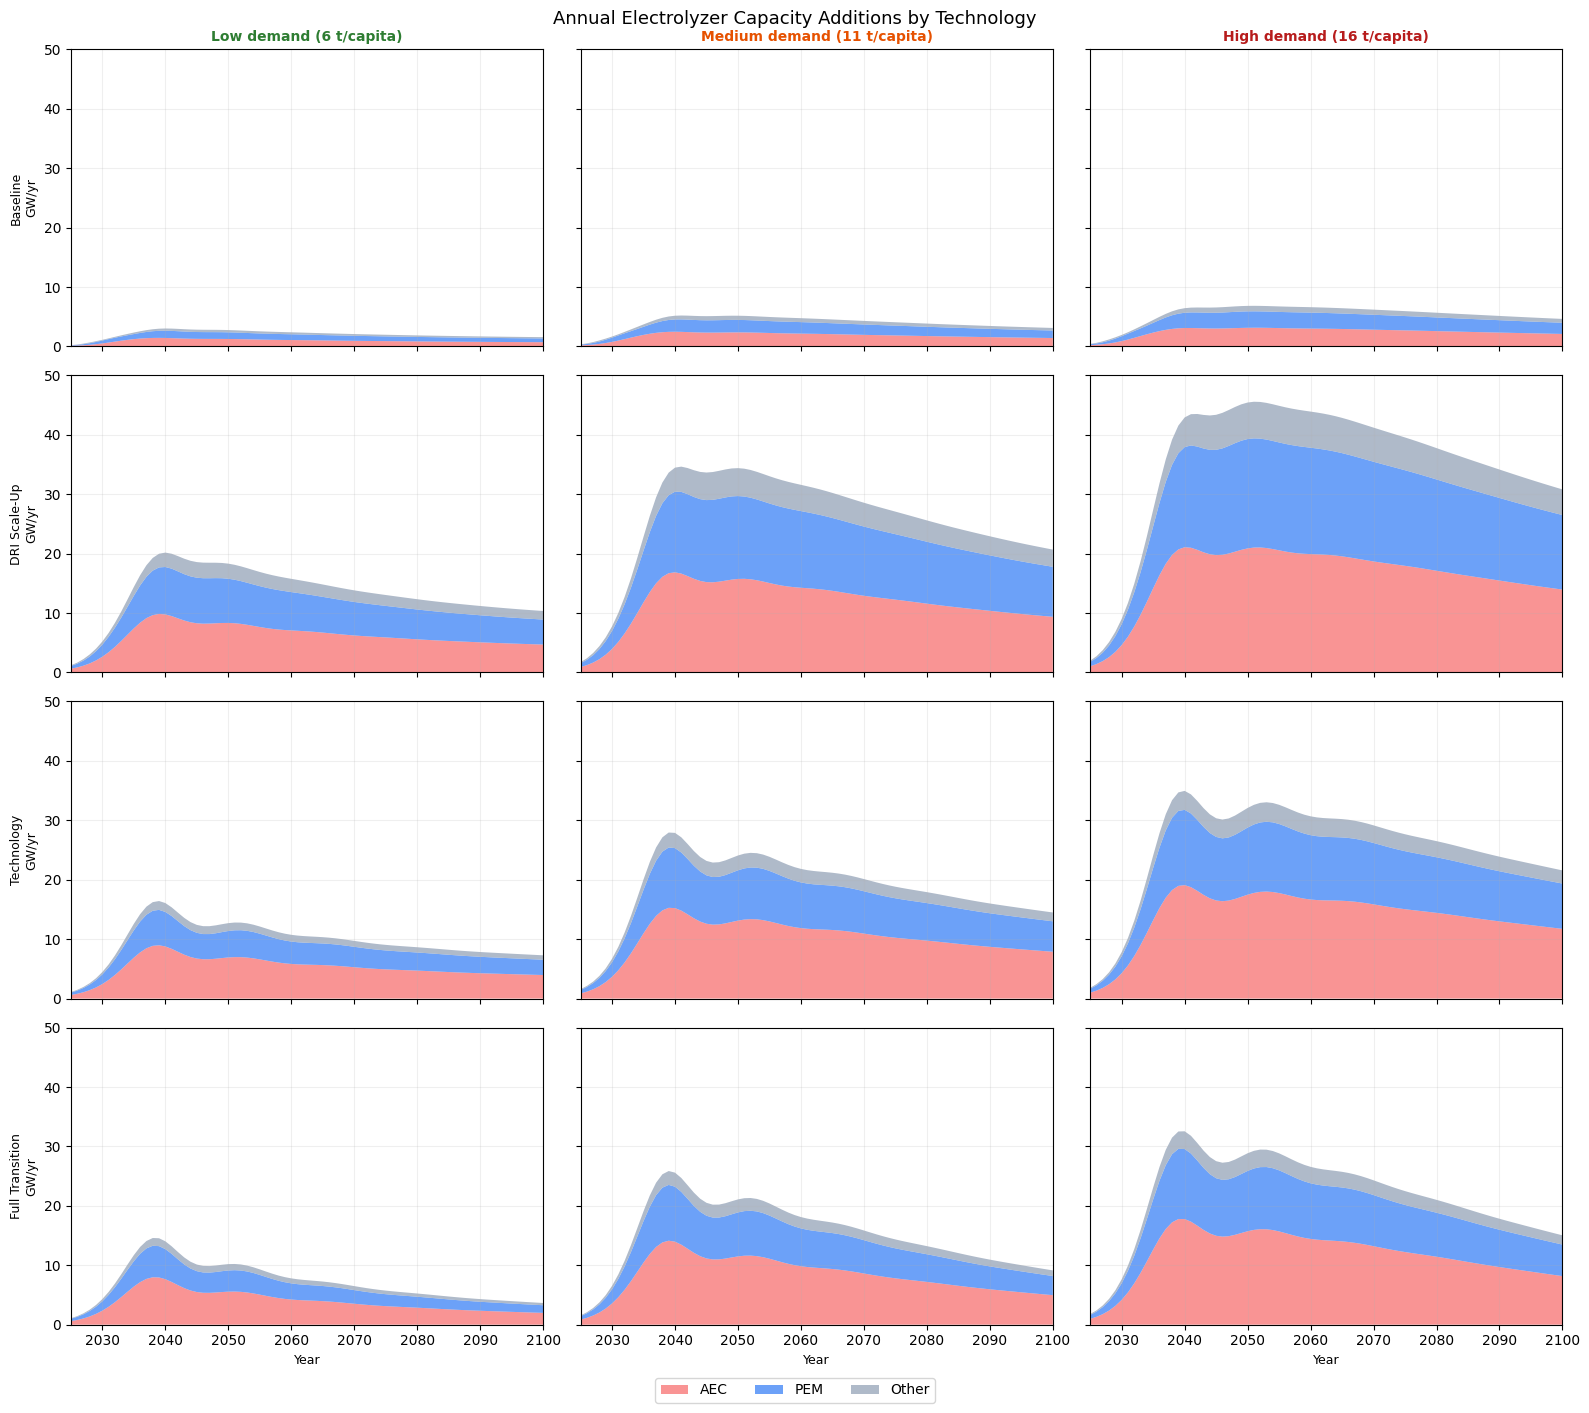

In [88]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14),
                          sharey=True, sharex=True)
fig.suptitle('Annual Electrolyzer Capacity Additions by Technology', fontsize=13)

for r, ambition in enumerate(ambition_levels):
    for c, demand in enumerate(demand_levels):
        ax  = axes[r][c]
        dsm = scenarios[f'{demand}-{ambition}']['dsm_elec']

        ax.stackplot(plot_years,
                     dsm['i_AEC'], dsm['i_PEM'], dsm['i_Other'],
                     colors=cap_colors, alpha=0.75)

        ax.set_xlim(plot_years[3], plot_years[-1])
        ax.set_ylim(0, 50)
        ax.grid(True, alpha=0.2)

        if r == 0:
            ax.set_title(demand_labels[demand], fontsize=10,
                         fontweight='bold', color=demand_colors[demand])
        if c == 0:
            ax.set_ylabel(f'{ambition}\nGW/yr', fontsize=9)
        if r == 3:
            ax.set_xlabel('Year', fontsize=9)


cap_handles = [Patch(facecolor=c, alpha=0.75, label=l)
               for c, l in zip(cap_colors, cap_labels)]
fig.legend(handles=cap_handles, loc='lower center',
           ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig(viz_folder / 'electrolyzer_additions_all_scenarios.png',
            dpi=300, bbox_inches='tight')
plt.show()

## 9. Nickel demand for all scenarios

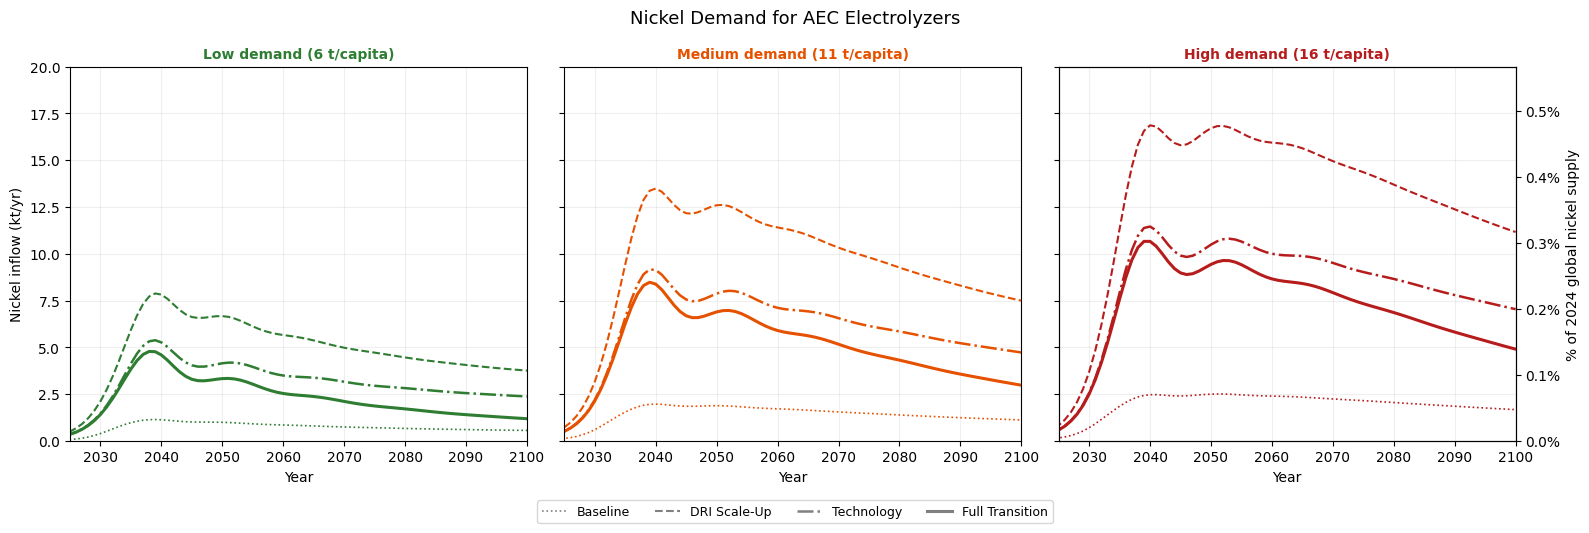

In [181]:
nickel_supply_2024 = 3526  # kt — INSG (2025)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, sharex=True)
fig.suptitle('Nickel Demand for AEC Electrolyzers', fontsize=13)

for c, demand in enumerate(demand_levels):
    ax = axes[c]

    for ambition in ambition_levels:
        name = f'{demand}-{ambition}'
        ax.plot(scenarios[name]['years'],
                scenarios[name]['materials']['nickel_inflow'],
                color=demand_colors[demand],
                linestyle=ambition_styles[ambition],
                linewidth=ambition_widths[ambition])

    ax.set_title(demand_labels[demand], fontsize=10,
                 fontweight='bold', color=demand_colors[demand])
    ax.set_xlabel('Year')
    ax.set_xlim(2025, 2100)
    ax.set_ylim(0, 20)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('Nickel inflow (kt/yr)')

# Secondary % axis on rightmost panel only
ax2 = axes[2].twinx()
ax2.set_ylim(0, axes[2].get_ylim()[1] / nickel_supply_2024 * 100)
ax2.set_ylabel('% of 2024 global nickel supply')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

from matplotlib.lines import Line2D
ambition_handles = [
    Line2D([0], [0], color='gray', linestyle=ambition_styles[a],
           linewidth=ambition_widths[a], label=a) for a in ambition_levels
]
fig.legend(handles=ambition_handles, loc='lower center',
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
plt.show()

# Save plot to vizualization folder
#fig.savefig(viz_folder / 'nickel_demand_aec_electrolyzers.png', dpi=300)

## 10. Iridium demand vs supply constraint for all scenarios

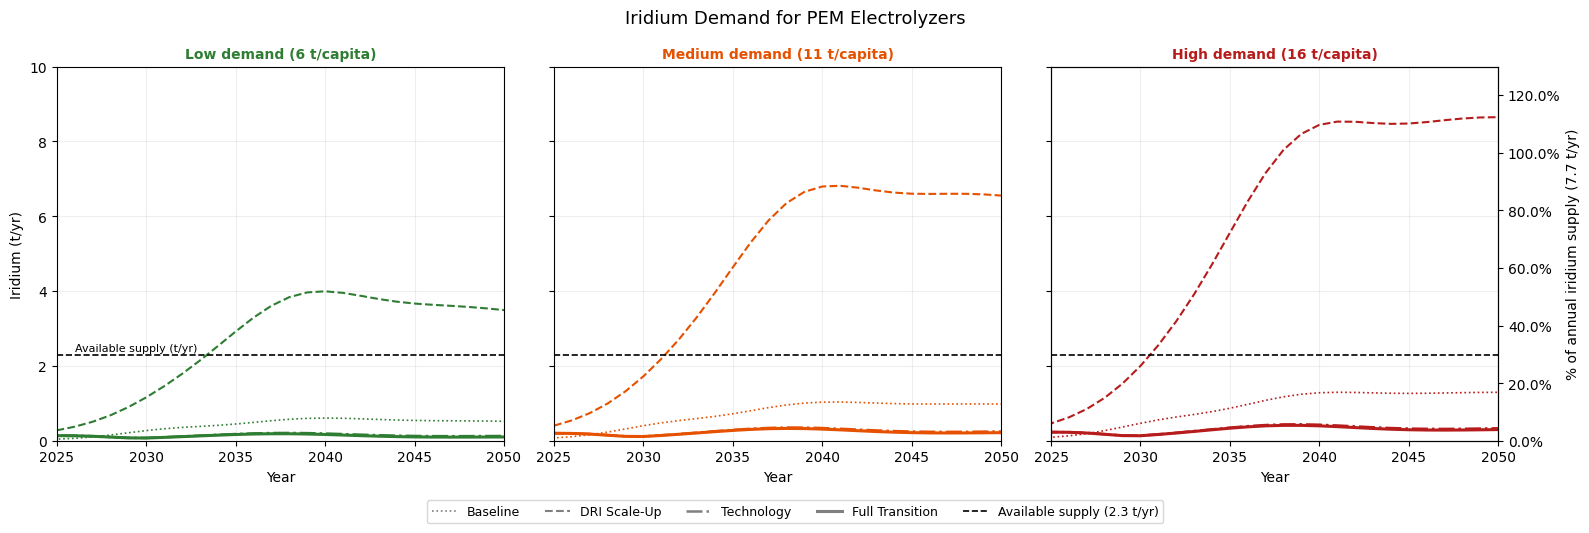

In [ ]:
iridium_supply_2024 = 7.7   # t/yr — Johnson Matthey (2024)
iridium_supply      = 7.3
other_demand        = 5.0
available           = iridium_supply - other_demand

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, sharex=True)
fig.suptitle('Iridium Demand for PEM Electrolyzers', fontsize=13)

for c, demand in enumerate(demand_levels):
    ax = axes[c]

    for ambition in ambition_levels:
        name = f'{demand}-{ambition}'
        ir   = scenarios[name]['materials']['iridium_inflow'] * 1000  # kt → t
        ax.plot(scenarios[name]['years'], ir,
                color=demand_colors[demand],
                linestyle=ambition_styles[ambition],
                linewidth=ambition_widths[ambition])

    ax.axhline(available, color='black', linewidth=1.2,
               linestyle='--', label='Available iridium supply')
    if c == 0:
        ax.text(2026, available + 0.05, f'Available supply (t/yr)',
                fontsize=8, va='bottom')

    ax.set_title(demand_labels[demand], fontsize=10,
                 fontweight='bold', color=demand_colors[demand])
    ax.set_xlabel('Year')
    ax.set_xlim(2025, 2050)
    ax.set_ylim(0, 10)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('Iridium (t/yr)')

# Secondary % axis on rightmost panel only
ax2 = axes[2].twinx()
ax2.set_ylim(0, axes[2].get_ylim()[1] / iridium_supply_2024 * 100)
ax2.set_ylabel('% of annual iridium supply (7.7 t/yr)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

from matplotlib.lines import Line2D
ambition_handles = [
    Line2D([0], [0], color='gray', linestyle=ambition_styles[a],
           linewidth=ambition_widths[a], label=a) for a in ambition_levels
] + [
    Line2D([0], [0], color='black', linewidth=1.2,
           linestyle='--', label=f'Available supply ({available:.1f} t/yr)')
]
fig.legend(handles=ambition_handles, loc='lower center',
           ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
#plt.savefig(viz_folder / 'iridium_demand_all_scenarios.png',
#            dpi=300, bbox_inches='tight')
plt.show()

# Save plot to vizualization folder
#fig.savefig(viz_folder / 'iridium_demand_pem_electrolyzers.png', dpi=300)

## 11. Pt demand for all scenarios

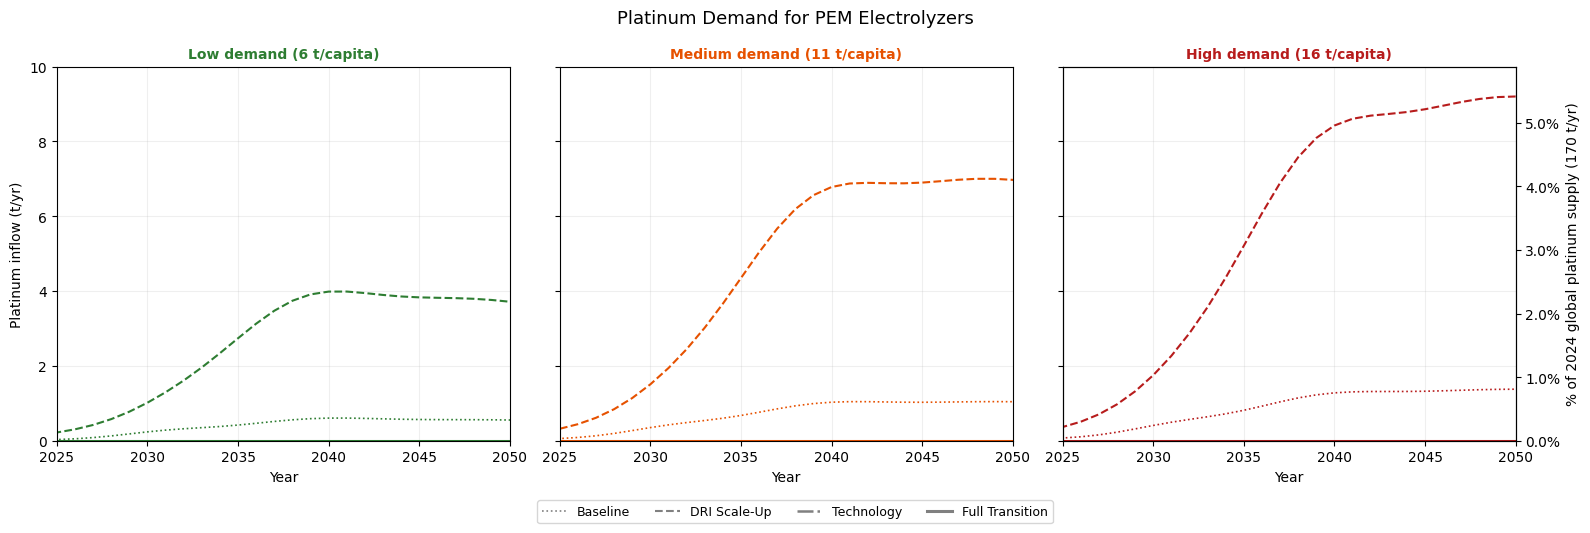

In [187]:
platinum_supply_2024 = 170  # t/yr — USGS (2025)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, sharex=True)
fig.suptitle('Platinum Demand for PEM Electrolyzers', fontsize=13)

for c, demand in enumerate(demand_levels):
    ax = axes[c]

    for ambition in ambition_levels:
        name = f'{demand}-{ambition}'
        pt   = scenarios[name]['materials']['platinum_inflow'] * 1000
        ax.plot(scenarios[name]['years'], pt,
                color=demand_colors[demand],
                linestyle=ambition_styles[ambition],
                linewidth=ambition_widths[ambition])

    ax.set_title(demand_labels[demand], fontsize=10,
                 fontweight='bold', color=demand_colors[demand])
    ax.set_xlabel('Year')
    ax.set_xlim(2025, 2050)
    ax.set_ylim(0, 10)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('Platinum inflow (t/yr)')

ax2 = axes[2].twinx()
ax2.set_ylim(0, axes[2].get_ylim()[1] / platinum_supply_2024 * 100)
ax2.set_ylabel('% of 2024 global platinum supply (170 t/yr)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

from matplotlib.lines import Line2D
ambition_handles = [
    Line2D([0], [0], color='gray', linestyle=ambition_styles[a],
           linewidth=ambition_widths[a], label=a) for a in ambition_levels
]
fig.legend(handles=ambition_handles, loc='lower center',
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
#plt.savefig(viz_folder / 'platinum_demand_all_scenarios.png',
#            dpi=300, bbox_inches='tight')
plt.show()